##### Features
- Also called L2 regularization
- Reduce overfitting
- Use square of coefficient
- Keep all features

In [145]:
import pandas as pd

In [146]:
df=pd.read_csv("https://raw.githubusercontent.com/Arannamoy/datasets/refs/heads/main/Algerian%20Forest%20Fire%20Dataset/Algerian_forest_fires_dataset.csv")

In [147]:
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.0 KB


In [149]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,127,9
top,1,7,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


In [150]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [151]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [152]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  Region       247 non-null    float64
dtypes: float64(1), str(14)
memory usage: 39.9 KB


In [154]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
Region         0
dtype: int64

In [155]:
df=df.dropna().reset_index(drop=True)

In [156]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [157]:
df.iloc[122]

day                    day
month                month
year                  year
Temperature    Temperature
 RH                     RH
 Ws                     Ws
Rain                 Rain 
FFMC                  FFMC
DMC                    DMC
DC                      DC
ISI                    ISI
BUI                    BUI
FWI                    FWI
Classes          Classes  
Region                 1.0
Name: 122, dtype: object

In [158]:
df=df.drop(122).reset_index(drop=True)

In [159]:
df.iloc[122]

day                      1
month                    6
year                  2012
Temperature             32
 RH                     71
 Ws                     12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
Region                 1.0
Name: 122, dtype: object

In [160]:
df.columns=df.columns.str.strip()

In [161]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [162]:
df[["Temperature","RH","Ws","Rain","FFMC","DMC","DC","ISI","BUI","FWI"]]=df[["Temperature","RH","Ws","Rain","FFMC","DMC","DC","ISI","BUI","FWI"]].astype("float32")

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    str    
 1   month        243 non-null    str    
 2   year         243 non-null    str    
 3   Temperature  243 non-null    float32
 4   RH           243 non-null    float32
 5   Ws           243 non-null    float32
 6   Rain         243 non-null    float32
 7   FFMC         243 non-null    float32
 8   DMC          243 non-null    float32
 9   DC           243 non-null    float32
 10  ISI          243 non-null    float32
 11  BUI          243 non-null    float32
 12  FWI          243 non-null    float32
 13  Classes      243 non-null    str    
 14  Region       243 non-null    float64
dtypes: float32(10), float64(1), str(4)
memory usage: 22.9 KB


In [164]:
df.drop(columns=["day","month","year"])

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29.0,57.0,18.0,0.0,65.699997,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29.0,61.0,13.0,1.3,64.400002,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26.0,82.0,22.0,13.1,47.099998,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25.0,89.0,13.0,2.5,28.600000,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27.0,77.0,16.0,0.0,64.800003,3.0,14.2,1.2,3.9,0.5,not fire,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30.0,65.0,14.0,0.0,85.400002,16.0,44.5,4.5,16.9,6.5,fire,1.0
239,28.0,87.0,15.0,4.4,41.099998,6.5,8.0,0.1,6.2,0.0,not fire,1.0
240,27.0,87.0,29.0,0.5,45.900002,3.5,7.9,0.4,3.4,0.2,not fire,1.0
241,24.0,54.0,18.0,0.1,79.699997,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [165]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["Classes"]=encoder.fit_transform(df['Classes'])
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57.0,18.0,0.0,65.699997,3.4,7.6,1.3,3.4,0.5,5,0.0
1,2,6,2012,29.0,61.0,13.0,1.3,64.400002,4.1,7.6,1.0,3.9,0.4,5,0.0
2,3,6,2012,26.0,82.0,22.0,13.1,47.099998,2.5,7.1,0.3,2.7,0.1,5,0.0
3,4,6,2012,25.0,89.0,13.0,2.5,28.600000,1.3,6.9,0.0,1.7,0.0,5,0.0
4,5,6,2012,27.0,77.0,16.0,0.0,64.800003,3.0,14.2,1.2,3.9,0.5,5,0.0


In [166]:
df['Classes']=encoder.inverse_transform(df['Classes'])
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57.0,18.0,0.0,65.699997,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29.0,61.0,13.0,1.3,64.400002,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,3,6,2012,26.0,82.0,22.0,13.1,47.099998,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25.0,89.0,13.0,2.5,28.600000,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,5,6,2012,27.0,77.0,16.0,0.0,64.800003,3.0,14.2,1.2,3.9,0.5,not fire,0.0


[]

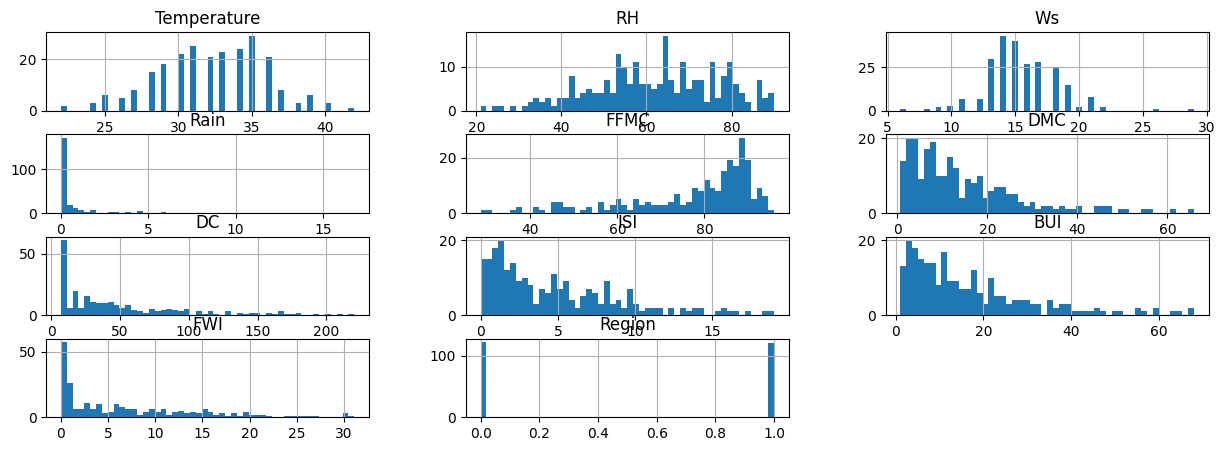

In [167]:
import matplotlib.pyplot as plt
%matplotlib inline
df.hist(bins=50,figsize=(15,5))
plt.plot()

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [169]:
X_train,X_test,y_train,y_test=train_test_split(df[["Temperature","RH","Ws","Rain","FFMC","DMC","DC","ISI","BUI"]],df["FWI"],random_state=42,test_size=0.2)

In [170]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [171]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.9882726073265076

In [172]:
from sklearn.linear_model import Lasso
lr=Lasso()
lr.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.952791690826416

In [ ]:
from sklearn.linear_model import Ridge
lr=Ridge()
lr.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.9813747406005859

In [175]:
from sklearn.linear_model import ElasticNet
lr=ElasticNet()
lr.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.867220401763916

In [179]:
from sklearn.linear_model import LassoCV,ElasticNetCV,RidgeCV
cv1=LassoCV()
cv1.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.867220401763916

In [180]:
cv1=ElasticNetCV()
cv1.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.867220401763916

In [181]:
cv1=RidgeCV()
cv1.fit(X_train,y_train)
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
score

0.867220401763916